In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error,r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_raw = pd.read_csv('Air Traffic Data Final.csv',parse_dates=['Date'],index_col='Date')
df_raw.head()

,dom_pass,int_pass,dom_freight,int_freight,gdp,population,jet_fuel,inflation,unemployment,exchange_rate
Date,,,,,,,,,,
2009-01-01,3288004.0,885435.0,20832.0,11675.0,1.341890e+12,1225524753,71.75,10.88,7.66,48.70
2009-02-01,3293220.0,757168.0,18645.0,12482.0,1.341890e+12,1225524753,61.97,10.88,7.66,49.25
2009-03-01,3122400.0,848046.0,23046.0,15359.0,1.341890e+12,1225524753,65.01,10.88,7.66,51.13
2009-04-01,3266686.0,861715.0,21623.0,14512.0,1.341890e+12,1225524753,68.55,10.88,7.66,49.97
2009-05-01,3883887.0,898410.0,19534.0,14586.0,1.341890e+12,1225524753,72.22,10.88,7.66,48.51


Defining target and feature columns

In [3]:
target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

Creating simplified features

In [4]:
def create_simplified_features(df):
    """
    PATH 1: Creates the SIMPLIFIED feature set for dom_pass
    (6 lags, time features, rolling avg)
    """
    n_lags = 6
    df_with_features = df.copy()
    
    # Lags
    for col in (target_cols + exog_cols):
        for i in range(1, n_lags + 1):
            df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
    
    # Time features
    df_with_features['month'] = df_with_features.index.month
    df_with_features['quarter'] = df_with_features.index.quarter
    
    # Rolling features
    for col in target_cols:
        df_with_features[f'{col}_roll_avg_3'] = df_with_features[col].shift(1).rolling(window=3).mean()
        
    df_with_features = df_with_features.dropna()
    return df_with_features

Creating baseline features

In [5]:
def create_baseline_features(df):
    """
    PATH 2: Creates the ORIGINAL baseline feature set for dom_freight
    (12 lags, no other features)
    """
    n_lags = 12
    df_with_features = df.copy()
    
    # Lags only
    for col in (target_cols + exog_cols):
        for i in range(1, n_lags + 1):
            df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
            
    df_with_features = df_with_features.dropna()
    return df_with_features

# --- 2. Helper Function for Splitting & Scaling ---

def prepare_data(df_features, target_name):
    """
    Splits and scales the data for a single target
    """
    # Define X and y
    X = df_features.drop(columns=target_cols)
    y = df_features[[target_name]]
    
    # Split (80/20)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # Scale X
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Scale y
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled = scaler_y.transform(y_test)
    
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, y_test, scaler_X,scaler_y, X_train.index, X_test.index

Tuning and evaluating the best model

In [6]:
def tune_and_evaluate(X_train_scaled, y_train_scaled, X_test_scaled, y_test, scaler_y, target_name):
    """
    Performs GridSearchCV and evaluates the final best model
    """
    print(f"\n--- Tuning Model for: {target_name} ---")
    
    # Define the parameter grid to search
    # This is a small grid for speed. You can expand this.
    param_grid = {
        'n_estimators': [500, 1000],
        'learning_rate': [0.01, 0.09],
        'max_depth': [3, 5],
        'subsample': [0.7, 1.0] # % of data to use per tree
    }
    
    # Use TimeSeriesSplit for cross-validation. This is CRITICAL.
    # It ensures we don't validate on data from the past.
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Create GridSearchCV object
    grid_search = GridSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error', # We want to minimize error
        verbose=1
    )
    
    # Fit the grid search
    # .ravel() flattens the y_train array, which XGBoost prefers
    grid_search.fit(X_train_scaled, y_train_scaled.ravel())
    
    print(f"Best parameters found: {grid_search.best_params_}")
    
    # Get the best model
    best_model = grid_search.best_estimator_
    
    # --- Evaluation ---
    print(f"\n--- Final Performance for: {target_name} ---")
    
    # Predict on the test set
    y_pred_scaled = best_model.predict(X_test_scaled)
    
    # Inverse transform to original units
    y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_original = y_test.values.flatten() # Get original, unscaled values
    
    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)
    epsilon = 1e-10 
    mape = np.mean(np.abs((y_test_original - y_pred_original) / (y_test_original + epsilon))) * 100
    r2 = r2_score(y_test_original, y_pred_original)
    
    print(f"Final RMSE: {rmse:.2f}")
    print(f"Final MAE:  {mae:.2f}")
    print(f"Final MAPE: {mape:.2f} %")
    print(f"R2 score:  {r2:.2f}")
    
    # Plot
    plt.figure(figsize=(14, 7))
    plt.plot(y_test.index, y_test_original, label='Actual Values', color='blue')
    plt.plot(y_test.index, y_pred_original, label='Tuned Prediction', color='red', linestyle='--')
    plt.title(f'Final Tuned Model: {target_name}')
    plt.xlabel('Date')
    plt.ylabel('Original Units')
    plt.legend()
    plt.show()
    
    return best_model, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


--- Tuning Model for: dom_freight ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 1.0}

--- Final Performance for: dom_freight ---
Final RMSE: 9627.94
Final MAE:  7636.00
Final MAPE: 11.93 %
R2 score:  -2.51


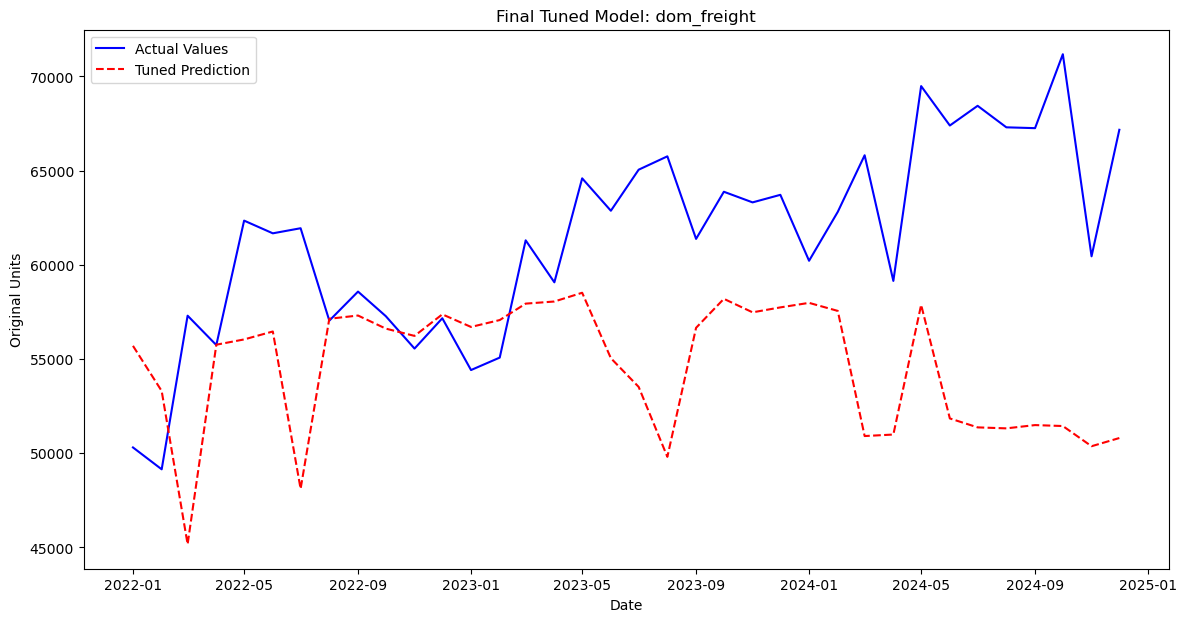



--- FINAL MODEL PERFORMANCE SUMMARY ---
                    RMSE          MAE       MAPE
dom_freight  9627.942393  7635.998589  11.932007


In [7]:
final_models = {}
final_results = {}

# --- PATH 2: Domestic Freight ---
df_freight_features = create_baseline_features(df_raw)
X_train_freight, X_test_freight, y_train_freight, y_test_freight_scaled, y_test_freight,scaler_X_freight, scaler_y_freight, _, _ = prepare_data(
    df_freight_features, 'dom_freight'
)
model_freight, results_freight = tune_and_evaluate(
    X_train_freight, y_train_freight, X_test_freight, y_test_freight, scaler_y_freight, 'dom_freight'
)
final_models['dom_freight'] = model_freight
final_results['dom_freight'] = results_freight

# --- 5. Final Summary ---
print("\n\n--- FINAL MODEL PERFORMANCE SUMMARY ---")
summary_df = pd.DataFrame(final_results).T
print(summary_df)


# We have found that this model give an accuracy of **86.08%** on the dom_freight using lags = 12 and 3-month rolling average

**Future Forecast**

In [8]:
future_date_str = '2025-01-01' # Example: The month *after* your last data point
future_exog_values = {
    'gdp': 3949765421913.18,            
    'population': 1486463625,    
    'jet_fuel': 179.04,
    'inflation': 4.62,
    'unemployment': 5.73,
    'exchange_rate': 84.8
}
print(f"\nForecasting for: {future_date_str}")


Forecasting for: 2025-01-01


In [9]:
def forecast_dom_freight(df_history, future_exog):
    """
    Forecasts the next step for domestic freight using
    the 'baseline' feature set (12 lags).
    """
    print("--- Building 'dom_freight' feature vector ---")
    
    feature_names = scaler_X_freight.get_feature_names_out()
    feature_dict = {}

    # 1. Add future exogenous values
    for col in future_exog:
        if col in feature_names:
            feature_dict[col] = future_exog[col]
            
    # 2. Add lag features (n_lags = 12)
    n_lags = 12
    all_cols_to_lag = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight', 
                       'gdp', 'population', 'jet_fuel', 'inflation', 
                       'unemployment', 'exchange_rate']
                       
    for col in all_cols_to_lag:
        for i in range(1, n_lags + 1):
            feature_name = f'{col}_lag_{i}'
            if feature_name in feature_names:
                feature_dict[feature_name] = df_history[col].iloc[-i]
                
    # 3. Convert to DataFrame and predict
    feature_row_df = pd.DataFrame([feature_dict], columns=feature_names)
    feature_row_scaled = scaler_X_freight.transform(feature_row_df)
    prediction_scaled = model_freight.predict(feature_row_scaled)
    prediction_original = scaler_y_freight.inverse_transform(prediction_scaled.reshape(-1, 1))
    
    return prediction_original[0][0]

In [10]:
final_freight_forecast = forecast_dom_freight(df_raw, future_exog_values)

--- Building 'dom_freight' feature vector ---


In [11]:
print("\n\n" + "="*30)
print("   🚀 FINAL FORECASTS 🚀")
print("="*30)
print(f"Forecast for Date: {future_date_str}")
print(f"Predicted Domestic Freight: {final_freight_forecast:,.0f}")
print("="*30)



   🚀 FINAL FORECASTS 🚀
Forecast for Date: 2025-01-01
Predicted Domestic Freight: 54,049
